In [1]:
from preload import *
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.proportion import proportion_confint


#color=['#2e317c','#134857','#1a6840','#2376b7','#619ac3','#0a9396','#f97d1c','#ca6702','#ee3f4d','#a61b29']
color=['#2D3074','#234755','#33674C','#6E99C1','#3D74B5','#429199','#E6DDD5','#E8843A','#DB4E5A','#9A2A2E']
FieldList=['Mathematics', 
 'Earth & Environmental Science','Social Sciences',
 'Physics','Chemistry','Materials Science', 
 'Engineering','Computer science',
'Biology','Medicine']


NameList=['Mathematics', 
 'GeoScience','Social Sciences',
'Physics','Chemistry','Materials Science', 'Engineering', 'Computer science',
'Biology','Medicine']
FN=dict(zip(FieldList,NameList))
FC=dict(zip(FieldList,color))
linewidth=3
ticklabel_fontsize=25
label_fontsize=20
title_fontsize=25
title_x_postion=-.15

plt.rcParams['font.family']=['Helvetica']

[ok] Loading ./FigureData/Fig_E4.pkl
==Time: 0.01, Memory used: 0.00 GB, Current Memory: 0.205811 GB==


Text(0, 0.5, 'Papers cited critically (%)')

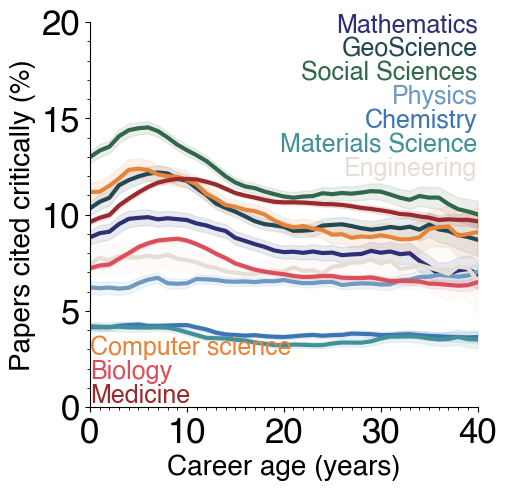

In [7]:
def np_move_avg(a,n,mode="valid"):
    return(np.convolve(a, np.ones((n,))/n, mode=mode))
window_size=3
k=0
fig=plt.figure(figsize=(5,5))
file='./FigureData/Fig_E4.pkl'
tmp = fun_load_pickle(file)
for field in FieldList:
    x=range(41)
    y=Field_Career_Q[field]
    line_kws={'lw':3}
    y1,y2 =  y[:,0]-y[:,1],y[:,0]+y[:,1]
    y1,y2 = np_move_avg(np.append(y1[:window_size-1],y1),window_size),np_move_avg(np.append(y2[:window_size-1],y2),window_size)
    plt.fill_between(np.array(x),y1,y2,color=FC[field],alpha=.1)
    #plt.step(x, y[:,0], where='mid', label='mid',color=color[k],lw=2)
    y0= np_move_avg(np.append(y[:window_size-1,0],y[:,0]),window_size)
    plt.plot(x,y0,color=FC[field],lw=linewidth) 
    if k<=6:
        plt.text(40,0.195-k/80,FN[field],fontsize=18,color =FC[field],ha='right') 
    else:
        plt.text(0,0.115-k/80,FN[field],fontsize=18,color =FC[field],ha='left') 
    k+=1
plt.xlim(0,40)
plt.ylim(0.,.15)
ax=plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.tick_params(axis='both', which='major', labelsize=ticklabel_fontsize)
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
plt.yticks([i/100 for i in range(0,20+1,5)],[str(i) for i in range(0,20+1,5)])
ax.yaxis.set_minor_locator(plt.MultipleLocator(.01))

plt.xlabel('Career age (years)',fontsize=label_fontsize)
plt.ylabel('Papers cited critically (%)',fontsize=label_fontsize)
